# ChIPnumはlog10, featuresはz-scoredで予測
pub numはlog10したあとにz-score化した

In [102]:
# load datatable
import pandas as pd
df_reg = pd.read_csv("/Users/saeko/Documents/MOCCS/important_chipseq_prediction/data/ignored_paper/df_reg_902TF_427var_log10.tsv", sep="\t")
df_reg.head()

,pub_num,ChIP_num,var1,var2,var3,var4,var5,var6,var7,var8,...,var418,var419,var420,var421,var422,var423,var424,var425,var426,var427
0,1.116860,0.301030,-1.221343,1.335732,1.266304,1.451134,-1.081191,-0.620464,1.128741,1.304912,...,1.104406,1.011349,1.212536,1.238126,1.125150,1.212249,1.125947,0.900949,0.714594,0.361582
1,2.187243,0.698970,-0.404102,-0.119716,0.966966,-0.772425,1.338718,-0.620444,1.116724,0.906000,...,0.665871,0.981769,0.933349,0.974418,0.977015,0.952512,0.855586,0.900949,0.714594,1.538638
2,2.748681,2.943989,0.118663,0.489127,0.806041,1.666712,-1.315808,-0.620462,0.301282,0.058831,...,-0.434575,-0.290427,-1.584552,-1.615123,-0.463752,-1.561771,-1.595916,-0.740499,-0.274564,-0.147543
3,0.756831,1.690196,-0.524076,0.748819,1.327742,1.620883,-1.265931,-0.620464,0.060395,0.297519,...,0.650365,0.634577,0.732693,0.740827,0.674407,0.798427,0.725416,0.844347,0.714594,0.316687
4,0.781191,0.477121,0.787040,1.178473,0.799100,1.646693,-1.294023,-0.620460,-0.075304,-0.174818,...,0.789717,0.868330,0.752055,0.690146,0.748773,0.650112,0.818241,0.617940,0.714594,-0.175999


<Axes: >

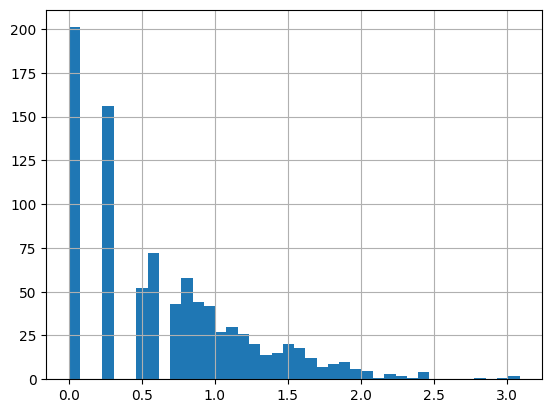

In [103]:
# histgram of pub_num, title: ChIP_seq
#df_reg['pub_num'].hist(bins=100)
df_reg['ChIP_num'].hist(bins=40)

In [104]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from tqdm import tqdm

In [105]:
features = [c for c in df_reg.columns if c != "ChIP_num"]
X = df_reg[features]
y = df_reg["ChIP_num"].values

#print(X)
#print(y)

# 1. XGBoost

In [ ]:
n_iter = 400
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=300,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

 25%|██▌       | 100/400 [03:06<08:42,  1.74s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_4154/1800328554.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 25%|██▌       | 101/400 [03:07<08:39,  1.74s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_4154/1800328554.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 26%|██▌       | 102/400 [03:09<08:52,  1.79s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_4154/1800328554.

Final RMSE: 0.483
Spearman correlation: 0.526


In [ ]:
# print(results)

# median_preds2 = results.median(axis=1, skipna=True)
# print(median_preds)
# print(median_preds2)

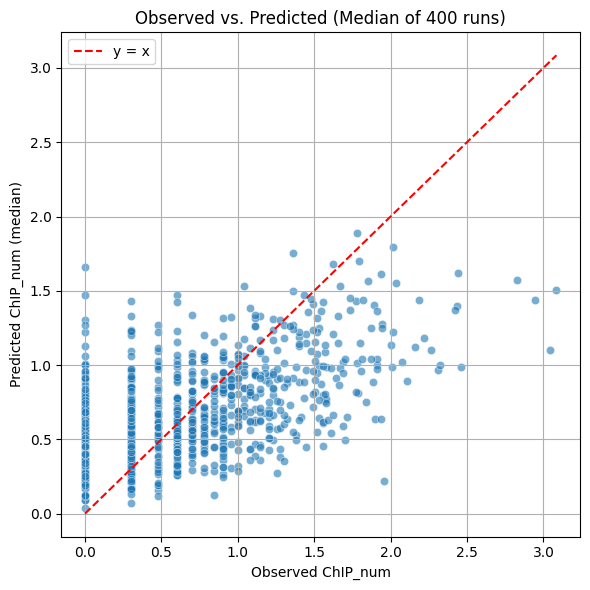

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


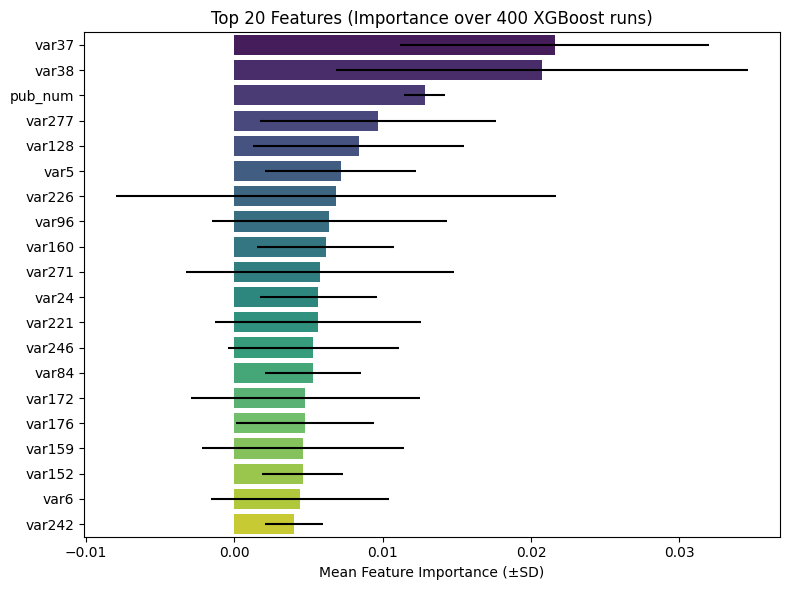

In [8]:
# 特徴量重要度を各反復ごとに保存
importance_list = []

for i in range(n_iter):
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)

    X_train = X.loc[train_idx]
    y_train = y[train_idx]

    model = XGBRegressor(
        n_estimators=300,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0
    )
    model.fit(X_train, y_train)

    # importance を dict → Series → DataFrame に変換
    imp = pd.Series(model.feature_importances_, index=features)
    importance_list.append(imp)

# すべての反復から DataFrame 化
importance_df = pd.DataFrame(importance_list)

# 平均と標準偏差を算出
mean_importance = importance_df.median().sort_values(ascending=False)
std_importance = importance_df.std()

# 上位20特徴量を可視化
top_n = 20
plt.figure(figsize=(8, 6))
sns.barplot(
    x=mean_importance.iloc[:top_n],
    y=mean_importance.index[:top_n],
    xerr=std_importance.loc[mean_importance.index[:top_n]],
    palette="viridis"
)
plt.xlabel("Mean Feature Importance (±SD)")
plt.title(f"Top {top_n} Features (Importance over {n_iter} XGBoost runs)")
plt.tight_layout()
plt.show()


# 設定を色々といじってみて試す
## 学習率を下げる

In [15]:
# 学習率を下げる
n_iter = 400
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=300,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0,
        learning_rate=0.05
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds



 25%|██▌       | 100/400 [08:13<24:39,  4.93s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/1986436507.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 25%|██▌       | 101/400 [08:18<24:33,  4.93s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/1986436507.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 26%|██▌       | 102/400 [08:23<24:41,  4.97s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/19864365

NameError: name 'TRUE' is not defined

In [19]:
# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

Final RMSE: 0.483
Spearman correlation: 0.528


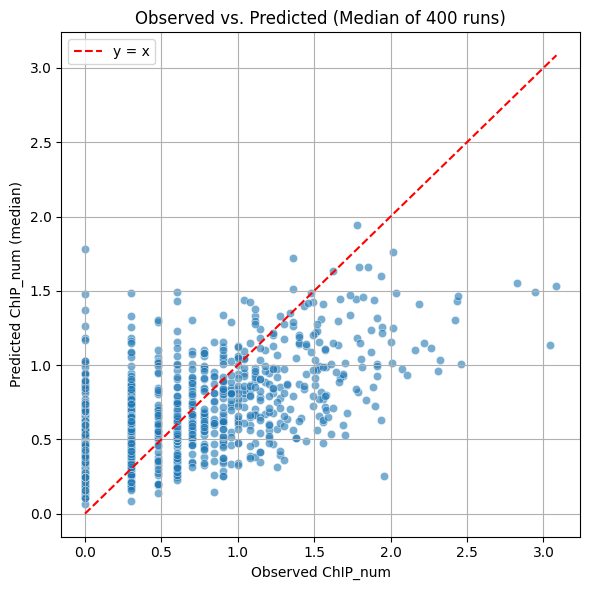

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 木数を上げる

In [ ]:
# 木数↑を上げる
n_iter = 400
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=2000,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

  4%|▎         | 14/400 [43:35<20:01:45, 186.80s/it]


KeyboardInterrupt: 

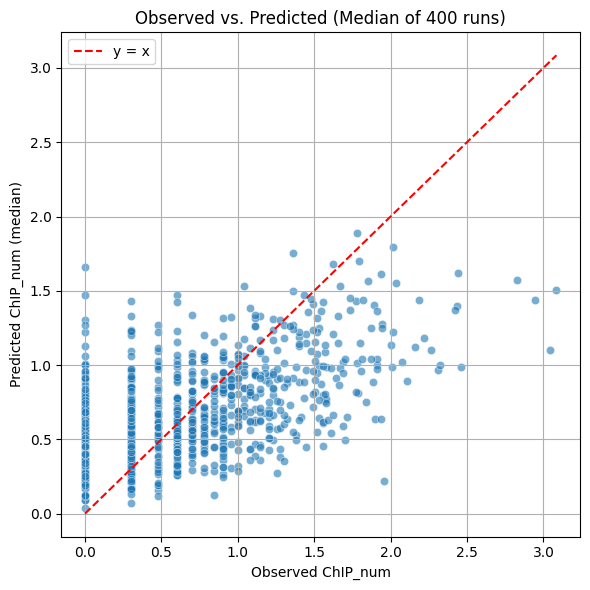

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 学習率を下げて木数を上げる

In [23]:
n_iter = 400
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（i再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=2000,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0,
        learning_rate=0.05
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

 25%|██▌       | 100/400 [17:58<51:35, 10.32s/it] /var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/3989473943.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 25%|██▌       | 101/400 [18:09<52:41, 10.57s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/3989473943.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 26%|██▌       | 102/400 [18:21<53:55, 10.86s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/3989473

Final RMSE: 0.483
Spearman correlation: 0.527


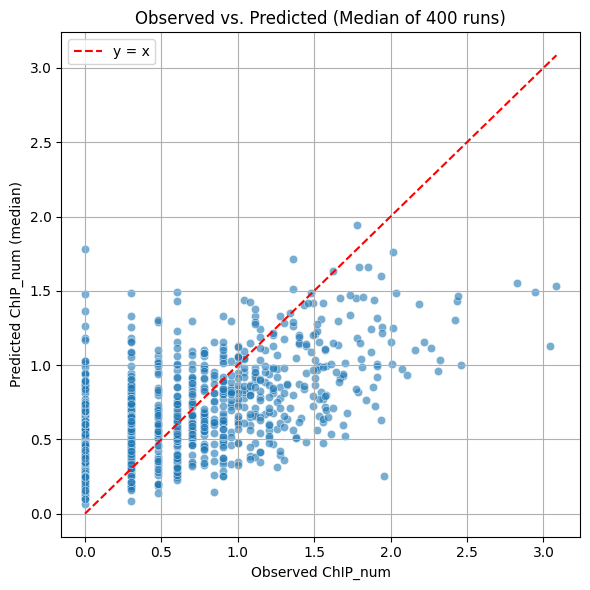

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## max depthを上げてみる

In [27]:
n_iter = 400
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（i再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=2000,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0,
        max_depth=10,            # ← 深くする（例: 10）
        grow_policy="lossguide", # ← max_leaves を使うにはこれを追加
        max_leaves=256 
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

 25%|██▌       | 100/400 [10:59<32:50,  6.57s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/1750512987.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 25%|██▌       | 101/400 [11:06<32:34,  6.54s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/1750512987.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 26%|██▌       | 102/400 [11:12<32:21,  6.52s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/17505129

Final RMSE: 0.495
Spearman correlation: 0.495


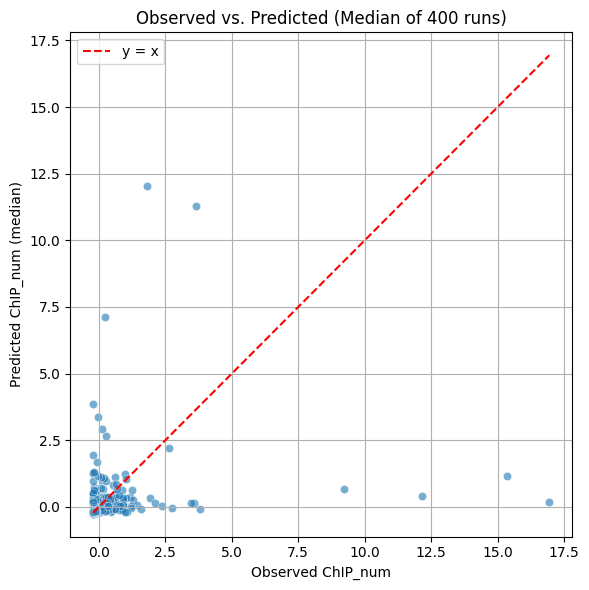

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 外れ値penalty, MAE

In [ ]:
n_iter = 400
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（i再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=300,
        #objective="reg:squarederror",
        objective="reg:absoluteerror", # 外れ値にペナルティを与える目的関数
        random_state=i,
        verbosity=0
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

100%|██████████| 3/3 [38:53<00:00, 777.78s/it]

Final RMSE: 0.487
Spearman correlation: 0.508


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## RMSEではなく、pseudohuberを使ってみる -> あまり変わらなかった。

In [59]:
import numpy as np

def pseudo_huber_loss(preds, dtrain):
    labels = dtrain.get_label()
    d = preds - labels
    delta = 1.0  # ハイパーパラメータ（大きいとMSEに近く、小さいとMAEに近づく）
    scale = delta ** 2
    grad = d / np.sqrt(1 + (d / delta) ** 2)
    hess = scale / (scale + d ** 2) ** 1.5
    return grad, hess


In [67]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
from tqdm import tqdm

# 自作 Pseudo-Huber loss
def pseudo_huber_loss(preds, dtrain):
    labels = dtrain.get_label()
    d = preds - labels
    delta = 1.0
    scale = delta ** 2
    grad = d / np.sqrt(1 + (d / delta) ** 2)
    hess = scale / (scale + d ** 2) ** 1.5
    return grad, hess

# 結果を保存するためのDataFrame
n_iter = 400
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # インデックス分割
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # DMatrixに変換
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test)

    # パラメータ
    params = {
        "seed": i,
        "verbosity": 0
    }

    # 学習
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        obj=pseudo_huber_loss  # ← custom loss をここに渡す
    )

    # 予測
    preds = pd.Series(model.predict(dtest), index=test_idx)
    results[f"run_{i}"] = preds

# 中央値で集約
median_preds = results.median(axis=1, skipna=True)

# 評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx]))
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx])

print(f"Final RMSE: {rmse:.3f}")
print(f"Spearman correlation: {corr:.3f}")


 25%|██▌       | 100/400 [06:56<19:18,  3.86s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/1565999703.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 25%|██▌       | 101/400 [07:00<19:17,  3.87s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/1565999703.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 26%|██▌       | 102/400 [07:04<19:13,  3.87s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/15659997

Final RMSE: 0.487
Spearman correlation: 0.527


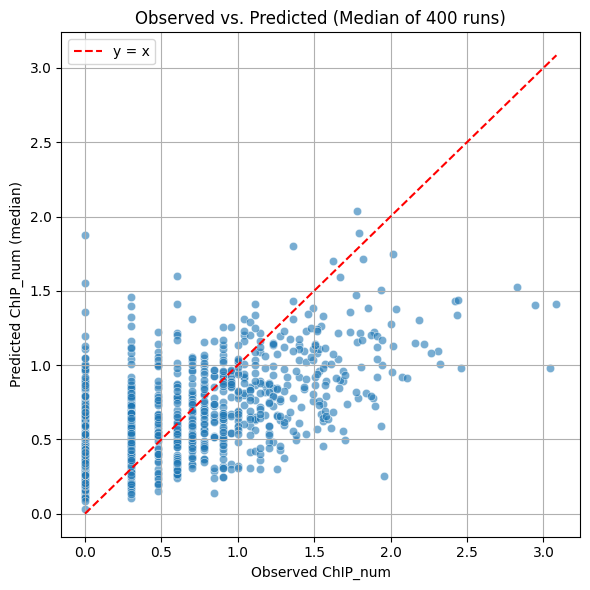

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 外れ値ならサンプルの重みを軽くする + MAEで計算

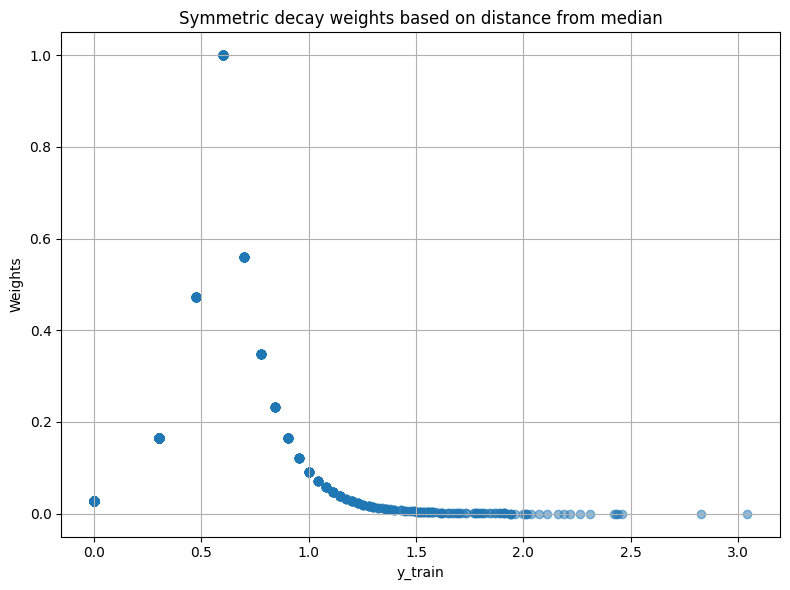

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# 中央値との差
median_val = np.median(y_train)
delta = y_train - median_val  # 対称な距離

# 重み設定：中央値から離れると急減（双方向とも）
weights = np.exp(-np.abs(delta) * 6)  # ← 係数3は調整可（大きいほど急に落ちる）

# 可視化
plt.figure(figsize=(8, 6))
plt.scatter(y_train, weights, alpha=0.5)
plt.xlabel("y_train")
plt.ylabel("Weights")
plt.title("Symmetric decay weights based on distance from median")
plt.grid(True)
plt.tight_layout()
plt.show()


In [74]:


n_iter = 400
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（i再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=300,
        objective="reg:absoluteerror",  # 外れ値にペナルティを与える目的関数
        random_state=i,
        verbosity=0,
        sample_weight=weights
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

 25%|██▌       | 100/400 [09:13<29:29,  5.90s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/2534750889.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 25%|██▌       | 101/400 [09:18<28:11,  5.66s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/2534750889.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 26%|██▌       | 102/400 [09:23<27:19,  5.50s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/25347508

Final RMSE: 0.483
Spearman correlation: 0.532


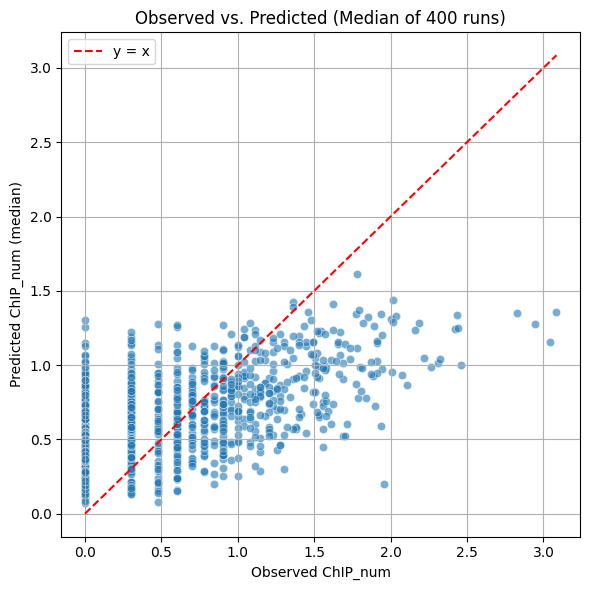

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 分割回数を少なくして試す。

In [130]:
# 学習率を下げる
n_iter = 1
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=300,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

100%|██████████| 1/1 [00:02<00:00,  2.09s/it]

Final RMSE: 0.434
Spearman correlation: 0.607


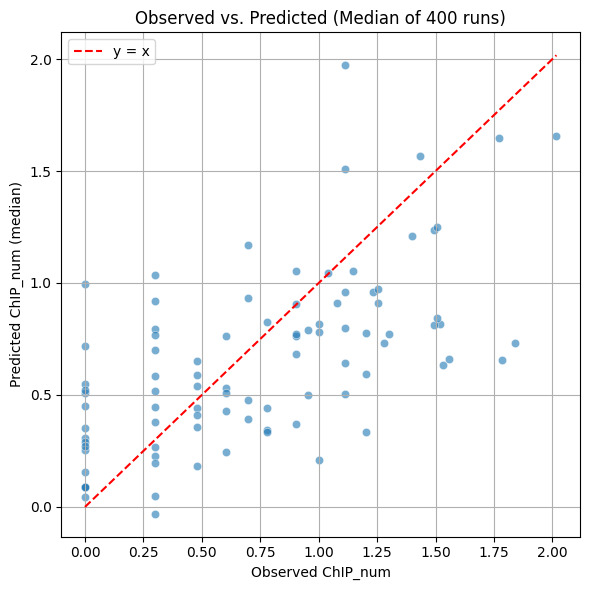

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## XGBRegressorではなく、元のxgb.trainで同じことをやってみる

In [ ]:
from sklearn.model_selection import train_test_split

2.0.0
[0]	train-rmse:0.47293	eval-rmse:0.59837
[1]	train-rmse:0.40163	eval-rmse:0.57831
[2]	train-rmse:0.34438	eval-rmse:0.55855
[3]	train-rmse:0.30076	eval-rmse:0.55951
[4]	train-rmse:0.26021	eval-rmse:0.56166
[5]	train-rmse:0.23256	eval-rmse:0.55851
[6]	train-rmse:0.20960	eval-rmse:0.55460
[7]	train-rmse:0.18915	eval-rmse:0.55652
[8]	train-rmse:0.16873	eval-rmse:0.55459
[9]	train-rmse:0.15326	eval-rmse:0.56295
[10]	train-rmse:0.13800	eval-rmse:0.56206
[11]	train-rmse:0.12475	eval-rmse:0.56296
[12]	train-rmse:0.11088	eval-rmse:0.56294
[13]	train-rmse:0.09868	eval-rmse:0.56171
[14]	train-rmse:0.09213	eval-rmse:0.56080
[15]	train-rmse:0.08287	eval-rmse:0.56195
[16]	train-rmse:0.07560	eval-rmse:0.56223
[17]	train-rmse:0.07355	eval-rmse:0.56231
[18]	train-rmse:0.06917	eval-rmse:0.55972
[19]	train-rmse:0.06506	eval-rmse:0.55976
[20]	train-rmse:0.06139	eval-rmse:0.55921
[21]	train-rmse:0.05848	eval-rmse:0.55946
[22]	train-rmse:0.05432	eval-rmse:0.55880
[23]	train-rmse:0.04931	eval-rmse:0.55

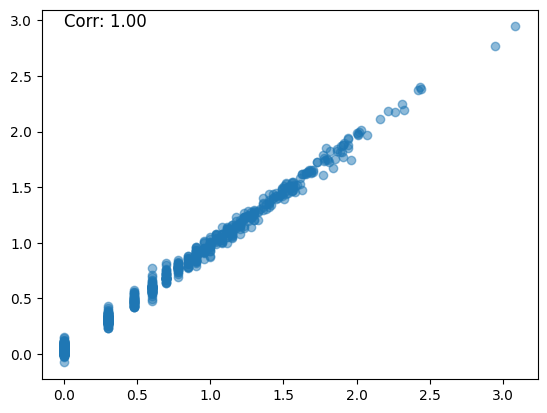

In [121]:
# model 作成
#!pip install xgboost
import xgboost as xgb
print(xgb.__version__)


# データの分割
train, test = train_test_split(df_reg, test_size = 0.1)

X_train = train[features]
y_train = train["ChIP_num"].values
X_test = test[features]
y_test = test["ChIP_num"].values

# データ形式の変換
dtrain = xgb.DMatrix(X_train, y_train)
dtest = xgb.DMatrix(X_test, y_test)

# パラメータ設定
# regression: 回帰, squarederror: 二乗誤差
params = {"objective": "reg:squarederror",'eval_metric': 'rmse','booster': 'gbtree', 'seed': 2525}

#学習過程を取得するための変数を用意
evals_result = {}
model = xgb.train(#上で設定した学習パラメータを使用
                params=params,
                dtrain=dtrain,
                #学習のラウンド数
                num_boost_round=100000,
                #early stoppinguのラウンド数
                early_stopping_rounds=15,
                #検証用データ
                evals=[(dtrain, 'train'), (dtest, 'eval')],
                #上で用意した変数を設定
                evals_result=evals_result)

# 予測結果
import matplotlib.pyplot as plt
import numpy as np

preds = model.predict(dtrain)
corr = np.corrcoef(y_train, preds)[0, 1]
plt.scatter(y_train, preds, alpha = 0.5)
#plt.plot(np.arange(0, 1), np.arange(0, 1), "r-")
plt.plot()
plt.text(np.min(y_train), np.max(preds), f'Corr: {corr:.2f}', fontsize=12)
plt.show() 

In [ ]:
# 分割をランダムに繰り返して学習
import xgboost as xgb
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

n_iter = 4
results = pd.DataFrame(index=df_reg.index)

for i in tqdm(range(n_iter)):
    # データ分割（ランダム 90%/10%）
    train_df, test_df = train_test_split(df_reg, test_size=0.1, random_state=i)

    X_train = train_df[features]
    y_train = train_df["ChIP_num"].values
    X_test = test_df[features]
    y_test = test_df["ChIP_num"].values

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "booster": "gbtree",
        "seed": i,
        "verbosity": 0  # ログ出力を抑制
    }

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=100000,
        early_stopping_rounds=15,
        evals=[(dtrain, 'train'), (dtest, 'eval')],
        evals_result=evals_result,
        verbose_eval=False  # ← 途中出力を抑制する設定
    )

    preds = pd.Series(model.predict(dtest), index=test_df.index)
    results[f"run_{i}"] = preds

# 予測中央値で集約
median_preds = results.median(axis=1, skipna=True)
valid_idx = median_preds.dropna().index
y_true = df_reg.loc[valid_idx, "ChIP_num"].values
y_pred = median_preds.loc[valid_idx].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
corr, _ = spearmanr(y_true, y_pred)

print(f"Final RMSE: {rmse:.3f}")
print(f"Spearman correlation: {corr:.3f}")


SyntaxError: invalid syntax (2020510005.py, line 40)

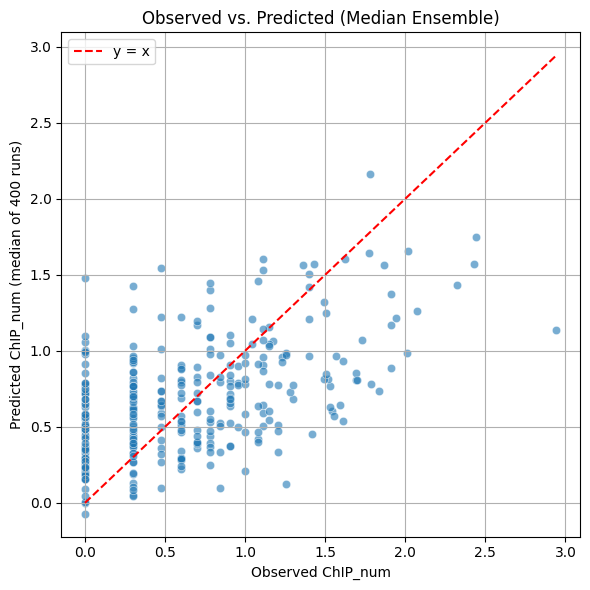

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測値のSeries（indexで一致）
true_vals = pd.Series(y_true, index=valid_idx)
pred_vals = pd.Series(y_pred, index=valid_idx)

# 散布図
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()],
         color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median of 400 runs)")
plt.title("Observed vs. Predicted (Median Ensemble)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 目的変数もz-score化して再度try

<Axes: >

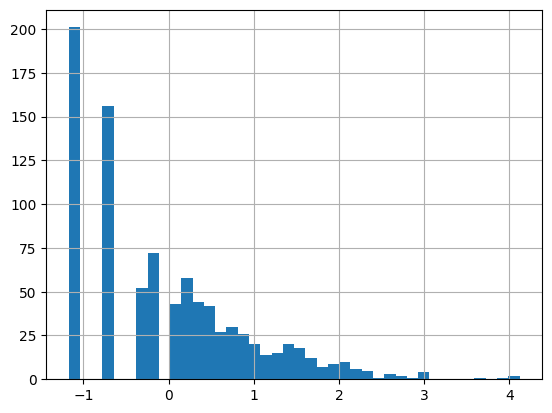

In [82]:
# load datatable
df_reg_z = pd.read_csv("/Users/saeko/Documents/MOCCS/important_chipseq_prediction/data/ignored_paper/df_reg_902TF_427var_log10_Z.tsv", sep="\t")
df_reg_z.head()

# summary of df_reg_z of ChIP_num
df_reg_z['ChIP_num_log10_z'].describe()
df_reg_z['ChIP_num_log10_z'].hist(bins=40)

In [84]:
features = [c for c in df_reg_z.columns if c != "ChIP_num_log10_z"]
X = df_reg_z[features]
y = df_reg_z["ChIP_num_log10_z"].values

#print(X)
#print(y)

In [85]:


n_iter = 400
results = pd.DataFrame(index=df_reg_z.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（i再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg_z.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=300,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

 25%|██▌       | 100/400 [04:00<13:13,  2.65s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/3351274969.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 25%|██▌       | 101/400 [04:01<12:03,  2.42s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/3351274969.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 26%|██▌       | 102/400 [04:03<11:11,  2.25s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/33512749

Final RMSE: 0.828
Spearman correlation: 0.526


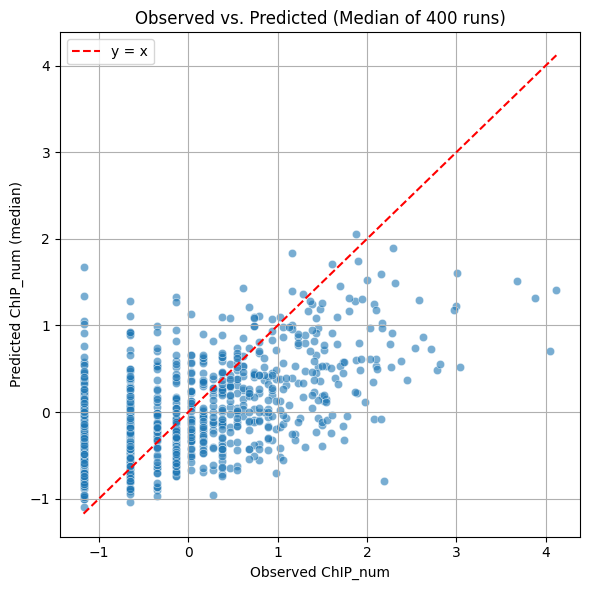

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 目的変数をただz-score化してtry

<Axes: >

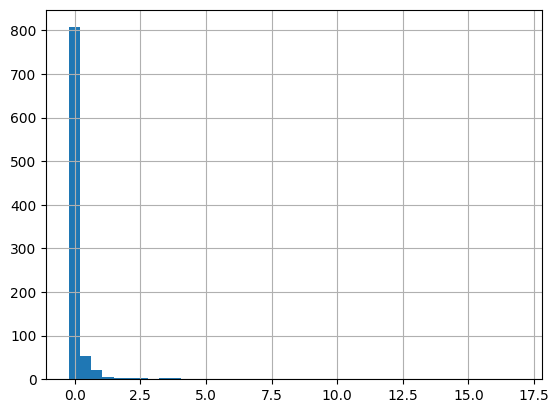

In [87]:
df_reg_z_only = pd.read_csv("/Users/saeko/Documents/MOCCS/important_chipseq_prediction/data/ignored_paper/df_reg_902TF_427var.tsv", sep="\t")
df_reg_z_only.head()

# summary of df_reg_z of ChIP_num
df_reg_z_only['ChIP_num'].describe()
df_reg_z_only['ChIP_num'].hist(bins=40)

In [88]:
features = [c for c in df_reg_z_only.columns if c != "ChIP_num"]
X = df_reg_z_only[features]
y = df_reg_z_only["ChIP_num"].values

#print(X)
#print(y)

In [89]:


n_iter = 400
results = pd.DataFrame(index=df_reg_z_only.index)

for i in tqdm(range(n_iter)):
    # 90% train / 10% test にランダム分割（i再現性のためrandom_state使用）
    train_idx, test_idx = train_test_split(df_reg_z_only.index, test_size=0.1, shuffle=True, random_state=i)
    
    X_train = X.loc[train_idx]
    y_train = y[train_idx]
    X_test = X.loc[test_idx]
    y_test = y[test_idx]
    
    # XGBoostモデル構築（RMSE目的）
    model = XGBRegressor(
        n_estimators=300,
        objective="reg:squarederror",
        random_state=i,
        verbosity=0
    )
    model.fit(X_train, y_train) #training

    # テストデータの予測値を保存（index一致させる）
    preds = pd.Series(model.predict(X_test), index=test_idx)
    results[f"run_{i}"] = preds

# 各TFの中央値予測を集約
median_preds = results.median(axis=1, skipna=True)

# 有効なインデックスで評価
valid_idx = median_preds.dropna().index
rmse = np.sqrt(mean_squared_error(y[valid_idx], median_preds[valid_idx])) #平均二乗誤差（MSE）計算 -> 平方根でRMSEへ
corr, _ = spearmanr(y[valid_idx], median_preds[valid_idx]) #スピアマン順位相関係数, 戻り値は (corr係数, p値) 

print(f"Final RMSE: {rmse:.3f}") #小数点以下3桁で表示
print(f"Spearman correlation: {corr:.3f}") #小数点以下3桁で表示

 25%|██▌       | 100/400 [03:03<09:14,  1.85s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/3410824637.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 25%|██▌       | 101/400 [03:05<09:04,  1.82s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/3410824637.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results[f"run_{i}"] = preds
 26%|██▌       | 102/400 [03:06<08:50,  1.78s/it]/var/folders/gt/yr0x_0q53_scww07ywj9l1qm0000gn/T/ipykernel_87490/34108246

Final RMSE: 1.091
Spearman correlation: 0.437


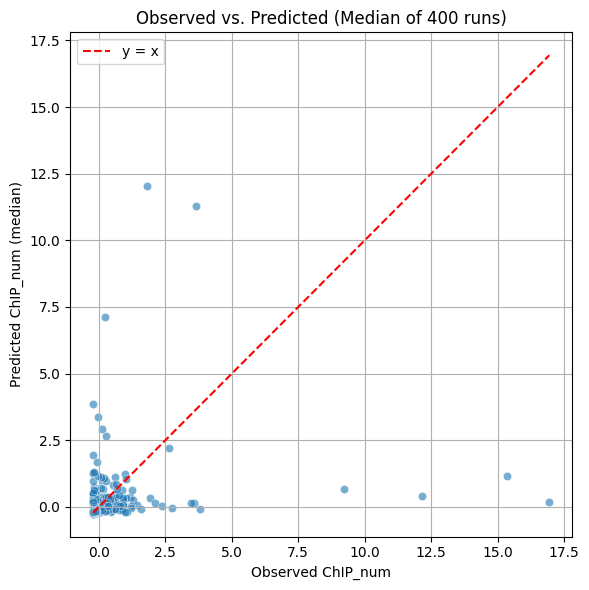

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# 実測値と予測中央値のSeriesを揃える
true_vals = pd.Series(y, index=df_reg.index).loc[valid_idx]
pred_vals = median_preds.loc[valid_idx]

# 散布図を描画
plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_vals, y=pred_vals, alpha=0.6)
plt.plot([true_vals.min(), true_vals.max()],
         [true_vals.min(), true_vals.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("Observed ChIP_num")
plt.ylabel("Predicted ChIP_num (median)")
plt.title("Observed vs. Predicted (Median of 400 runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
# resultとfeature importanceの情報を出力
# 散布図で使った予測値と実測値のペア
scatter_df = pd.DataFrame({
    "Observed_ChIP_num": y[valid_idx],
    "Predicted_ChIP_num_median": median_preds[valid_idx]
})

scatter_df.to_csv("/Users/saeko/Unmeasured/data/xgboost/rev1/scatter_data.tsv", sep="\t", index_label="TF_name")


# 特徴量重要度の統計値（全反復）
importance_summary = pd.DataFrame({
    "Feature": mean_importance.index,
    "Mean_Importance": mean_importance.values,
    "Std_Importance": std_importance[mean_importance.index].values
})

importance_summary.to_csv("/Users/saeko/Unmeasured/data/xgboost/rev1/feature_importance_summary.tsv", sep="\t", index=False)